In [1]:

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd().resolve().parent
DATA_DIR = PROJECT_ROOT / 'data'
FIGURES_DIR = PROJECT_ROOT / 'figures'
FIG_DIR = FIGURES_DIR
MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / 'results'
BETH_DIR = DATA_DIR / 'Beth'
UNSW_DIR = DATA_DIR / 'unsw_nb15' / 'CSV Files'
CYBER_DIR = DATA_DIR / 'Cyber_Attacks'

paths = {
    'unsw_train': UNSW_DIR / 'UNSW_NB15_training-set.csv',
    'unsw_test': UNSW_DIR / 'UNSW_NB15_testing-set.csv',
    'beth_train': BETH_DIR / 'labelled_training_data.csv',
    'beth_test': BETH_DIR / 'labelled_testing_data.csv',
    'cyber': CYBER_DIR / 'cybersecurity_attacks.csv',
}

dfs = {}
dfs['unsw_train'] = pd.read_csv(paths['unsw_train'])
dfs['unsw_test'] = pd.read_csv(paths['unsw_test'])
dfs['beth_train'] = pd.read_csv(paths['beth_train'])
dfs['beth_test'] = pd.read_csv(paths['beth_test'])
dfs['cyber'] = pd.read_csv(paths['cyber'])

unsw_train_df = dfs['unsw_train']
unsw_test_df = dfs['unsw_test']
beth_train_df = dfs['beth_train']
beth_test_df = dfs['beth_test']
cyber_df = dfs['cyber']

print('All datasets loaded successfully.')
for k, v in dfs.items():
    print(f'  {k}: {v.shape}')


All datasets loaded successfully.
  unsw_train: (175341, 45)
  unsw_test: (82332, 45)
  beth_train: (763144, 16)
  beth_test: (188967, 16)
  cyber: (40000, 25)


# Network Security Capstone — Data Overview & Validation

**Author:** Kevin Egemba  
**Program:** Boston University — M.S. in Data Science  

## Purpose
This notebook validates the datasets used across the capstone before any modeling begins.

It is designed to answer a few foundational questions:

- Do these datasets support the modeling tasks claimed later in the project?
- Are labels present, interpretable, and suitable for evaluation?
- Are there obvious issues related to missingness, duplicates, skew, leakage risk, or high-cardinality fields?
- What constraints from the data should shape preprocessing, feature selection, and evaluation?

This notebook is intentionally focused on **data understanding, quality checks, and modeling readiness**.


## 1) Load Data with Sanity Checks

Each dataset is loaded and checked for:
- shape
- memory footprint
- missingness
- duplicate rows
- target distribution where applicable

If any of these checks fail, the issue is treated as a **data readiness problem**, not a modeling problem.


In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [3]:
from pathlib import Path
import pandas as pd

# -------------------------------
# Project Paths
# -------------------------------
PROJECT_ROOT = Path.cwd().resolve().parent
DATA_DIR = PROJECT_ROOT / "data"
FIGURES_DIR = PROJECT_ROOT / "figures"
RESULTS_DIR = PROJECT_ROOT / "results"

# -------------------------------
# Dataset Directories
# -------------------------------
BETH_DIR = DATA_DIR / "Beth"
UNSW_DIR = DATA_DIR / "unsw_nb15" / "CSV Files"
CYBER_DIR = DATA_DIR / "Cyber_Attacks"

# -------------------------------
# Required Files
# -------------------------------
required_files = {
    "BETH train": BETH_DIR / "labelled_training_data.csv",
    "BETH test": BETH_DIR / "labelled_testing_data.csv",
    "UNSW train": UNSW_DIR / "UNSW_NB15_training-set.csv",
    "UNSW test": UNSW_DIR / "UNSW_NB15_testing-set.csv",
    "Cyber Attacks": CYBER_DIR / "cybersecurity_attacks.csv",
}

# -------------------------------
# Validation Check
# -------------------------------
missing_files = {name: path for name, path in required_files.items() if not path.exists()}

if missing_files:
    missing_detail = "\n".join(f"- {name}: {path}" for name, path in missing_files.items())
    raise FileNotFoundError(f"Missing required files:\n{missing_detail}")

print("All required files found.\n")
for name, path in required_files.items():
    print(f"{name}: {path}")

All required files found.

BETH train: C:\Users\kegem\OneDrive\Datascience Masters\Network Security Capstone\data\Beth\labelled_training_data.csv
BETH test: C:\Users\kegem\OneDrive\Datascience Masters\Network Security Capstone\data\Beth\labelled_testing_data.csv
UNSW train: C:\Users\kegem\OneDrive\Datascience Masters\Network Security Capstone\data\unsw_nb15\CSV Files\UNSW_NB15_training-set.csv
UNSW test: C:\Users\kegem\OneDrive\Datascience Masters\Network Security Capstone\data\unsw_nb15\CSV Files\UNSW_NB15_testing-set.csv
Cyber Attacks: C:\Users\kegem\OneDrive\Datascience Masters\Network Security Capstone\data\Cyber_Attacks\cybersecurity_attacks.csv


In [4]:
# Load all datasets into dfs dictionary
dfs = {}
dfs["unsw_train"] = pd.read_csv(UNSW_DIR / "UNSW_NB15_training-set.csv")
dfs["unsw_test"] = pd.read_csv(UNSW_DIR / "UNSW_NB15_testing-set.csv")
dfs["beth_train"] = pd.read_csv(BETH_DIR / "labelled_training_data.csv")
dfs["beth_test"] = pd.read_csv(BETH_DIR / "labelled_testing_data.csv")
dfs["cyber"] = pd.read_csv(CYBER_DIR / "cybersecurity_attacks.csv")

print("Datasets loaded:")
for name, df in dfs.items():
    print(f"  {name}: {df.shape}")

Datasets loaded:
  unsw_train: (175341, 45)
  unsw_test: (82332, 45)
  beth_train: (763144, 16)
  beth_test: (188967, 16)
  cyber: (40000, 25)


In [5]:
def quick_profile(df: pd.DataFrame, target_cols=None, n=5):
    out = {}
    out["rows"] = int(df.shape[0])
    out["cols"] = int(df.shape[1])
    out["memory_mb"] = float(df.memory_usage(deep=True).sum() / (1024**2))
    out["missing_cells"] = int(df.isna().sum().sum())
    out["missing_rate"] = float(out["missing_cells"] / (df.shape[0]*df.shape[1])) if df.size else 0.0
    out["dup_rows"] = int(df.duplicated().sum())
    if target_cols:
        for c in target_cols:
            if c in df.columns:
                vc = df[c].value_counts(dropna=False)
                out[f"{c}_unique"] = int(vc.shape[0])
                out[f"{c}_top"] = str(vc.index[0])
    return out

profiles = []
if "unsw_train" in dfs:
    profiles.append({"dataset":"UNSW train", **quick_profile(dfs["unsw_train"], ["label","attack_cat"])})
if "unsw_test" in dfs:
    profiles.append({"dataset":"UNSW test", **quick_profile(dfs["unsw_test"], ["label","attack_cat"])})
if "beth_train" in dfs:
    profiles.append({"dataset":"BETH train", **quick_profile(dfs["beth_train"], ["evil","eventId"])})
if "beth_test" in dfs:
    profiles.append({"dataset":"BETH test", **quick_profile(dfs["beth_test"], ["evil","eventId"])})
if "cyber" in dfs:
    profiles.append({"dataset":"Cyber attacks", **quick_profile(dfs["cyber"], ["Attack Type","Anomaly Scores"])})

profile_df = pd.DataFrame(profiles).sort_values("dataset")
profile_df

,dataset,rows,cols,memory_mb,missing_cells,missing_rate,dup_rows,label_unique,label_top,attack_cat_unique,attack_cat_top,evil_unique,evil_top,eventId_unique,eventId_top,Attack Type_unique,Attack Type_top,Anomaly Scores_unique,Anomaly Scores_top
3,BETH test,188967,16,110.471003,0,0.000000,0,NaN,NaN,NaN,NaN,2.0,1,46.0,42,NaN,NaN,NaN,NaN
2,BETH train,763144,16,417.741128,0,0.000000,0,NaN,NaN,NaN,NaN,1.0,0,32.0,3,NaN,NaN,NaN,NaN
4,Cyber attacks,40000,25,59.762847,99929,0.099929,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,DDoS,9826.0,93.76
1,UNSW test,82332,45,44.835433,0,0.000000,0,2.0,1,10.0,Normal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,UNSW train,175341,45,95.556418,0,0.000000,0,2.0,1,10.0,Normal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Initial Validation Focus

At load time, this notebook checks three things that directly affect what is realistic later:

1. **Scale and compute constraints**  
   Large datasets may require sampling, dimensionality reduction, or model-specific compromises.

2. **Target validity**  
   A task is only as sound as its target. Missing, derived, or overly imbalanced labels must be identified early.

3. **Feature usability**  
   IDs, timestamps, payload-like text, and target-adjacent columns can inflate performance or break portability if handled carelessly.


## 2) Column Types and Risk Columns

In security datasets, several column families deserve early review:

- **Identifiers and timestamps**: can behave like lookup keys instead of generalizable features
- **High-cardinality text fields**: often require encoding decisions or exclusion
- **Target-adjacent fields**: can create leakage if they are directly or indirectly derived from the label

The goal is not to remove these columns blindly. The goal is to identify them explicitly before modeling.


In [6]:
def dtype_table(df: pd.DataFrame):
    d = df.dtypes.astype(str).value_counts().reset_index()
    d.columns = ["dtype","count"]
    return d

for name in ["unsw_train","beth_train","cyber"]:
    if name in dfs:
        print("\n", name, dfs[name].shape)
        display(dtype_table(dfs[name]))


 unsw_train (175341, 45)


,dtype,count
0,int64,30
1,float64,11
2,object,4



 beth_train (763144, 16)


,dtype,count
0,int64,10
1,object,5
2,float64,1



 cyber (40000, 25)


,dtype,count
0,object,21
1,int64,3
2,float64,1


In [7]:
risk_keywords = ["id","time","timestamp","ip","address","payload","log","signature","alert","warning","user","device","geo","proxy"]
def find_risk_cols(df):
    cols = []
    for c in df.columns:
        low = c.lower()
        if any(k in low for k in risk_keywords):
            cols.append(c)
    return cols

for name in ["unsw_train","beth_train","cyber"]:
    if name in dfs:
        rc = find_risk_cols(dfs[name])
        print(f"\n{name}: {len(rc)} potential risk columns")
        print(rc[:40])


unsw_train: 3 potential risk columns
['id', 'is_ftp_login', 'is_sm_ips_ports']

beth_train: 7 potential risk columns
['timestamp', 'processId', 'threadId', 'parentProcessId', 'userId', 'eventId', 'stackAddresses']

cyber: 13 potential risk columns
['Timestamp', 'Source IP Address', 'Destination IP Address', 'Payload Data', 'Alerts/Warnings', 'Attack Signature', 'User Information', 'Device Information', 'Geo-location Data', 'Proxy Information', 'Firewall Logs', 'IDS/IPS Alerts', 'Log Source']


## 3) Targets and Class Balance

This section validates whether each dataset supports its intended task.

- If the target is highly imbalanced, accuracy alone will be misleading.
- If the positive class is extremely rare or absent, the problem may be better framed as anomaly detection.
- If multiple attack categories exist, the notebook should clarify whether the task is binary or multiclass.

Class balance is summarized before any resampling or modeling.


In [8]:
def class_balance(df, col, top_n=10):
    vc = df[col].value_counts(dropna=False)
    out = vc.to_frame("count")
    out["pct"] = (out["count"] / out["count"].sum()).round(4)
    return out.head(top_n)

if "unsw_train" in dfs and "label" in dfs["unsw_train"].columns:
    print("UNSW train — label")
    display(class_balance(dfs["unsw_train"], "label"))
if "unsw_test" in dfs and "label" in dfs["unsw_test"].columns:
    print("UNSW test — label")
    display(class_balance(dfs["unsw_test"], "label"))

if "beth_train" in dfs and "evil" in dfs["beth_train"].columns:
    print("BETH train — evil")
    display(class_balance(dfs["beth_train"], "evil"))
if "beth_test" in dfs and "evil" in dfs["beth_test"].columns:
    print("BETH test — evil")
    display(class_balance(dfs["beth_test"], "evil"))

if "cyber" in dfs and "Attack Type" in dfs["cyber"].columns:
    print("Cyber attacks — Attack Type")
    display(class_balance(dfs["cyber"], "Attack Type"))

UNSW train — label


,count,pct
label,,
1,119341,0.6806
0,56000,0.3194


UNSW test — label


,count,pct
label,,
1,45332,0.5506
0,37000,0.4494


BETH train — evil


,count,pct
evil,,
0,763144,1.0


BETH test — evil


,count,pct
evil,,
1,158432,0.8384
0,30535,0.1616


Cyber attacks — Attack Type


,count,pct
Attack Type,,
DDoS,13428,0.3357
Malware,13307,0.3327
Intrusion,13265,0.3316


## 4) Numeric Shape: Skew and Outliers

Security telemetry is often highly skewed. That is expected.

This section measures skewness and visualizes representative numeric fields so that later notebooks can make informed choices about:
- scaling
- clipping
- log transforms
- robust models


In [9]:
def numeric_skew(df, max_cols=30):
    num = df.select_dtypes(include=["number"])
    if num.shape[1] == 0:
        return pd.DataFrame()
    sk = num.skew(numeric_only=True).sort_values(ascending=False)
    out = sk.to_frame("skew").head(max_cols)
    return out

for name in ["unsw_train","beth_train","cyber"]:
    if name in dfs:
        print("\nTop skewed numeric features:", name)
        display(numeric_skew(dfs[name], 15))


Top skewed numeric features: unsw_train


,skew
trans_depth,167.335829
response_body_len,76.340075
sbytes,45.303443
sloss,44.753662
dloss,41.380270
spkts,40.217703
dbytes,39.760864
dpkts,36.764114
dinpkt,29.679512
djit,29.543830



Top skewed numeric features: beth_train


,skew
userId,24.928611
sus,24.461773
returnValue,22.214803
parentProcessId,1.541522
eventId,1.159888
mountNamespace,1.116704
timestamp,0.139543
evil,0.000000
argsNum,-0.149396
processId,-3.069725



Top skewed numeric features: cyber


,skew
Source Port,0.024472
Destination Port,0.008106
Packet Length,-0.000482
Anomaly Scores,-0.011169


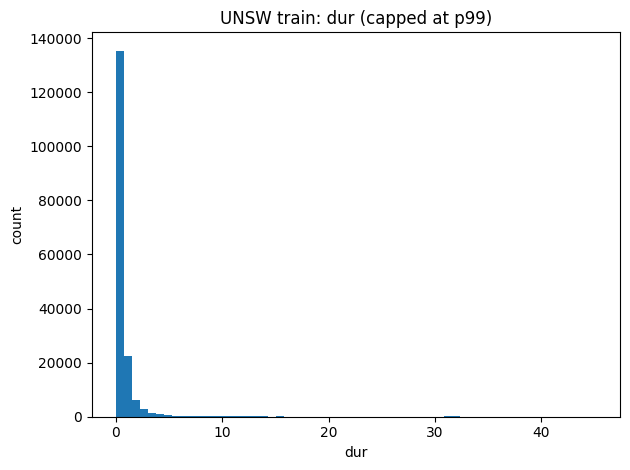

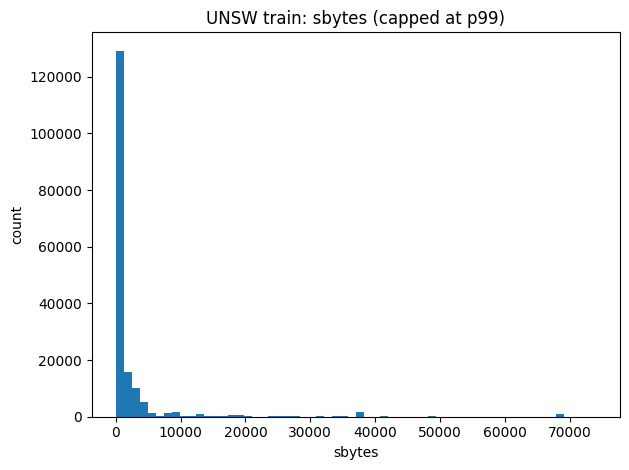

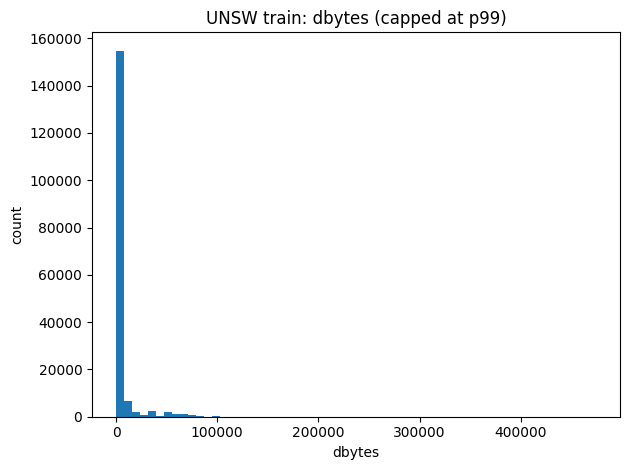

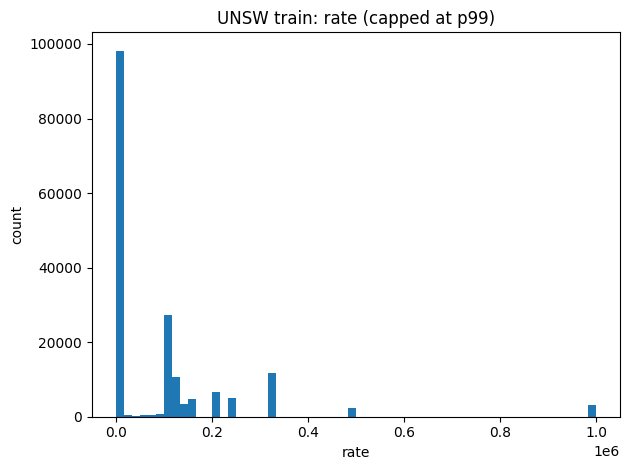

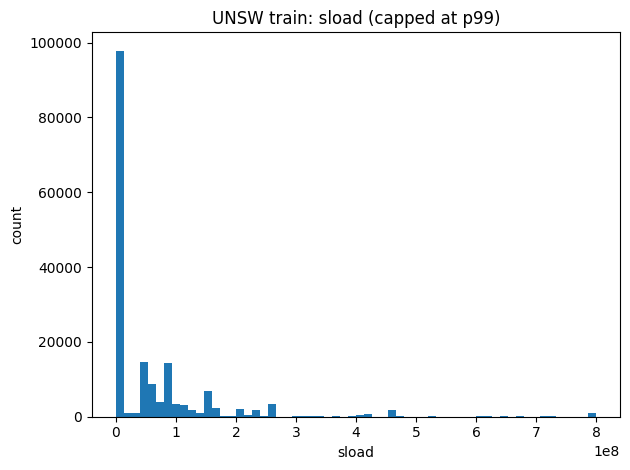

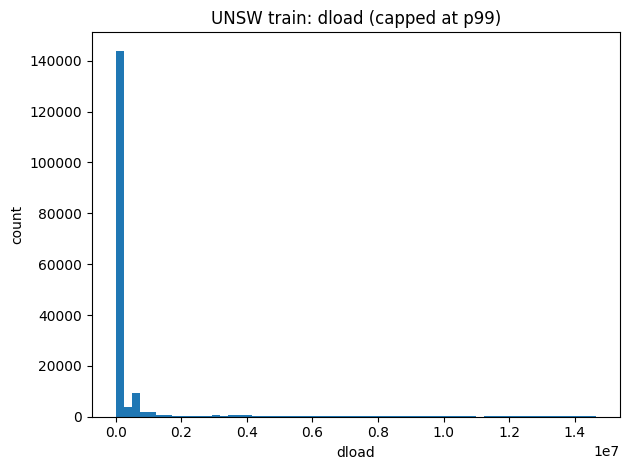

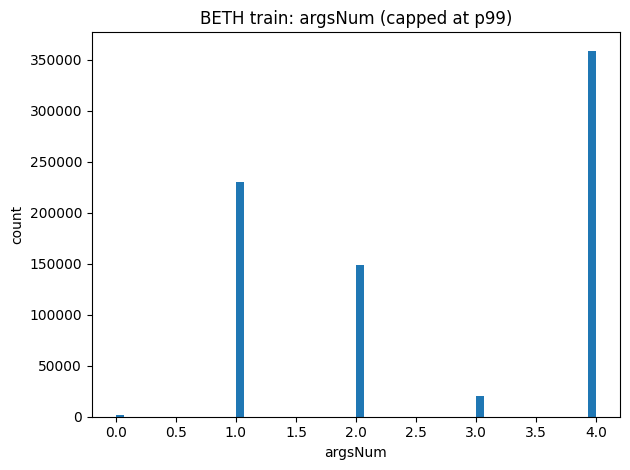

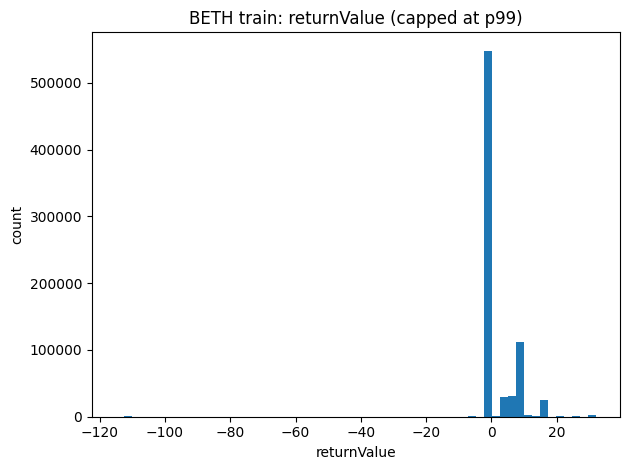

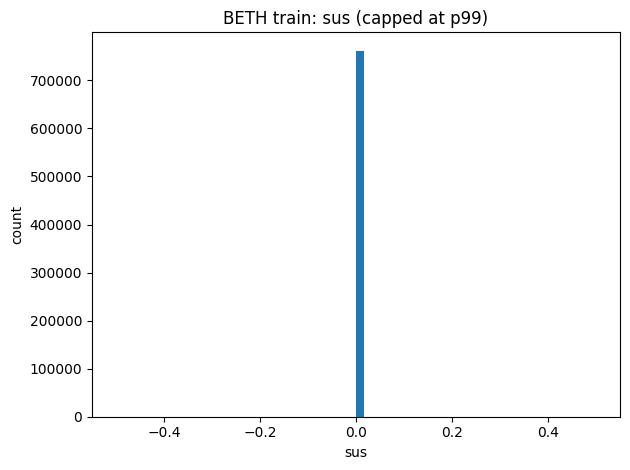

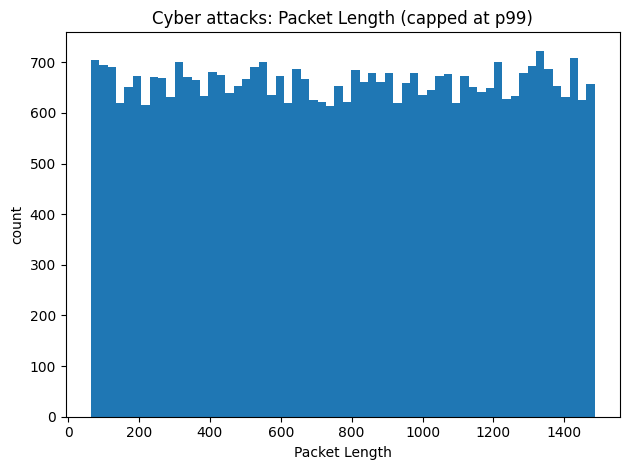

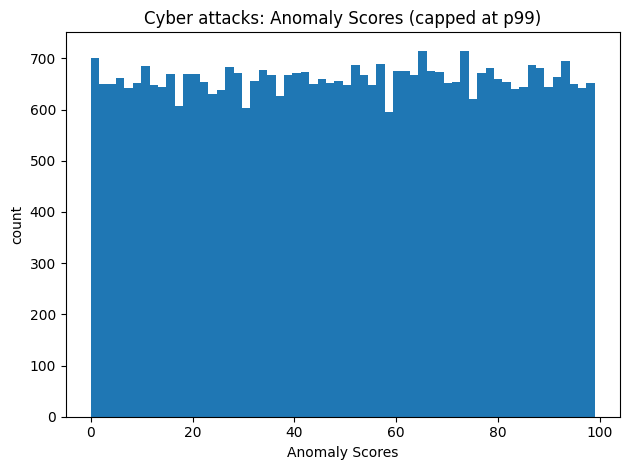

In [10]:
def plot_hist(df, cols, title):
    num = df.select_dtypes(include=["number"])
    cols = [c for c in cols if c in num.columns]
    if not cols:
        print("No requested columns found.")
        return
    for c in cols:
        plt.figure()
        s = num[c].dropna()
        # limit extreme tails for visibility
        cap = s.quantile(0.99)
        plt.hist(s[s <= cap], bins=60)
        plt.title(f"{title}: {c} (capped at p99)")
        plt.xlabel(c)
        plt.ylabel("count")
        plt.tight_layout()
        plt.show()

if "unsw_train" in dfs:
    plot_hist(dfs["unsw_train"], ["dur","sbytes","dbytes","rate","sload","dload"], "UNSW train")
if "beth_train" in dfs:
    plot_hist(dfs["beth_train"], ["argsNum","returnValue","sus"], "BETH train")
if "cyber" in dfs:
    plot_hist(dfs["cyber"], ["Packet Length","Anomaly Scores"], "Cyber attacks")

## 5) Leakage Checks

Two lightweight checks are used here to catch common leakage issues:

1. **Target-adjacent columns left in the feature space**
2. **Near-perfect correlations with the target**

This is not a full audit, but it is a strong guardrail against misleading early results.

### Interpreting Leakage-Risk Columns
A flagged column is not automatically leakage. It is a signal that the field deserves manual review before modeling.


In [11]:
def leakage_scan(df, target):
    if target not in df.columns:
        return pd.DataFrame()
    num = df.select_dtypes(include=["number"]).copy()
    if target in num.columns:
        y = num[target]
        X = num.drop(columns=[target])
    else:
        y = df[target]
        X = num
    corrs = X.corrwith(pd.to_numeric(y, errors="coerce")).abs().sort_values(ascending=False)
    out = corrs.head(15).to_frame("abs_corr_with_target")
    return out

if "unsw_train" in dfs and "label" in dfs["unsw_train"].columns:
    print("UNSW train leakage scan vs label")
    display(leakage_scan(dfs["unsw_train"], "label"))

if "beth_train" in dfs and "evil" in dfs["beth_train"].columns:
    print("BETH train leakage scan vs evil")
    display(leakage_scan(dfs["beth_train"], "evil"))

UNSW train leakage scan vs label


,abs_corr_with_target
id,0.727173
sttl,0.692741
ct_state_ttl,0.577704
dload,0.393739
ct_dst_sport_ltm,0.357213
dmean,0.341806
rate,0.337979
swin,0.333633
dwin,0.319626
ct_src_dport_ltm,0.305579


BETH train leakage scan vs evil


,abs_corr_with_target
timestamp,NaN
processId,NaN
threadId,NaN
parentProcessId,NaN
userId,NaN
mountNamespace,NaN
eventId,NaN
argsNum,NaN
returnValue,NaN
sus,NaN


In [12]:
unsw_train_df = pd.read_csv(paths["unsw_train"])
beth_train_df = pd.read_csv(paths["beth_train"])
cyber_df = pd.read_csv(paths["cyber"])

print("UNSW:", unsw_train_df.shape)
print("BETH:", beth_train_df.shape)
print("CYBER:", cyber_df.shape)


UNSW: (175341, 45)
BETH: (763144, 16)
CYBER: (40000, 25)


In [13]:
def dataset_profile(df, name, target=None):
    out = {}
    out["dataset"] = name
    out["rows"] = len(df)
    out["cols"] = df.shape[1]
    out["memory_mb"] = round(df.memory_usage(deep=True).sum() / (1024**2), 2)
    out["missing_cells"] = int(df.isna().sum().sum())
    out["duplicate_rows"] = int(df.duplicated().sum())
    out["numeric_cols"] = int(df.select_dtypes(include=[np.number]).shape[1])
    out["object_cols"] = int(df.select_dtypes(include=["object"]).shape[1])
    if target and target in df.columns:
        out["target_unique"] = int(df[target].nunique(dropna=False))
    return out

profiles = pd.DataFrame([
    dataset_profile(unsw_train_df, "UNSW train", "label"),
    dataset_profile(beth_train_df, "BETH train", "evil" if "evil" in beth_train_df.columns else None),
    dataset_profile(cyber_df, "Cyber", "Attack Type" if "Attack Type" in cyber_df.columns else None)
])

profiles


,dataset,rows,cols,memory_mb,missing_cells,duplicate_rows,numeric_cols,object_cols,target_unique
0,UNSW train,175341,45,95.56,0,0,41,4,2
1,BETH train,763144,16,417.74,0,0,11,5,1
2,Cyber,40000,25,59.76,99929,0,4,21,3


## UNSW-NB15 Overview

In [14]:
df = unsw_train_df.copy()

print("UNSW-NB15 (train) shape:", df.shape)
print("\nColumns:", df.columns.tolist())
display(df.head())


UNSW-NB15 (train) shape: (175341, 45)

Columns: ['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


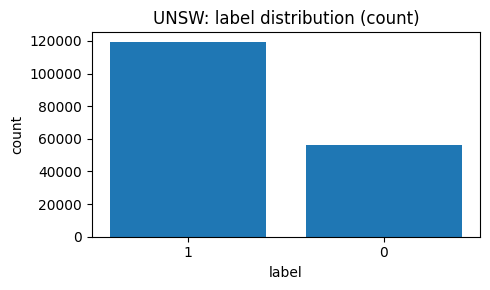

,pct
label,
1,0.6806
0,0.3194


In [15]:
target = "label"
vc = df[target].value_counts(dropna=False)

plt.figure(figsize=(5, 3))
plt.bar(vc.index.astype(str), vc.values)
plt.title("UNSW: label distribution (count)")
plt.xlabel("label")
plt.ylabel("count")
plt.tight_layout()
plt.savefig(FIG_DIR / "overview_unsw_label_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

display((vc / vc.sum()).rename("pct").round(4).to_frame())


In [16]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

desc = df[num_cols].describe().T
desc["skew"] = df[num_cols].skew(numeric_only=True)
desc = desc.sort_values("skew", key=lambda s: s.abs(), ascending=False)

print("Top skewed numeric features:")
print(desc[["mean","std","min","50%","max","skew"]].head(15))


Top skewed numeric features:
                           mean           std   min         50%           max  \
trans_depth        1.059821e-01  7.769108e-01   0.0       0.000  1.720000e+02   
response_body_len  2.144292e+03  5.420797e+04   0.0       0.000  6.558056e+06   
sbytes             8.844844e+03  1.747656e+05  28.0     430.000  1.296523e+07   
sloss              4.953000e+00  6.600506e+01   0.0       0.000  4.803000e+03   
dloss              6.948010e+00  5.273300e+01   0.0       0.000  5.484000e+03   
spkts              2.029866e+01  1.368876e+02   1.0       2.000  9.616000e+03   
dbytes             1.492892e+04  1.436542e+05   0.0     164.000  1.465555e+07   
dpkts              1.896959e+01  1.102583e+02   0.0       2.000  1.097400e+04   
dinpkt             8.821630e+01  9.870932e+02   0.0       0.006  5.671682e+04   
djit               6.043538e+02  4.061043e+03   0.0       0.000  2.893883e+05   
ct_flw_http_mthd   1.330664e-01  7.012076e-01   0.0       0.000  3.000000e+01   

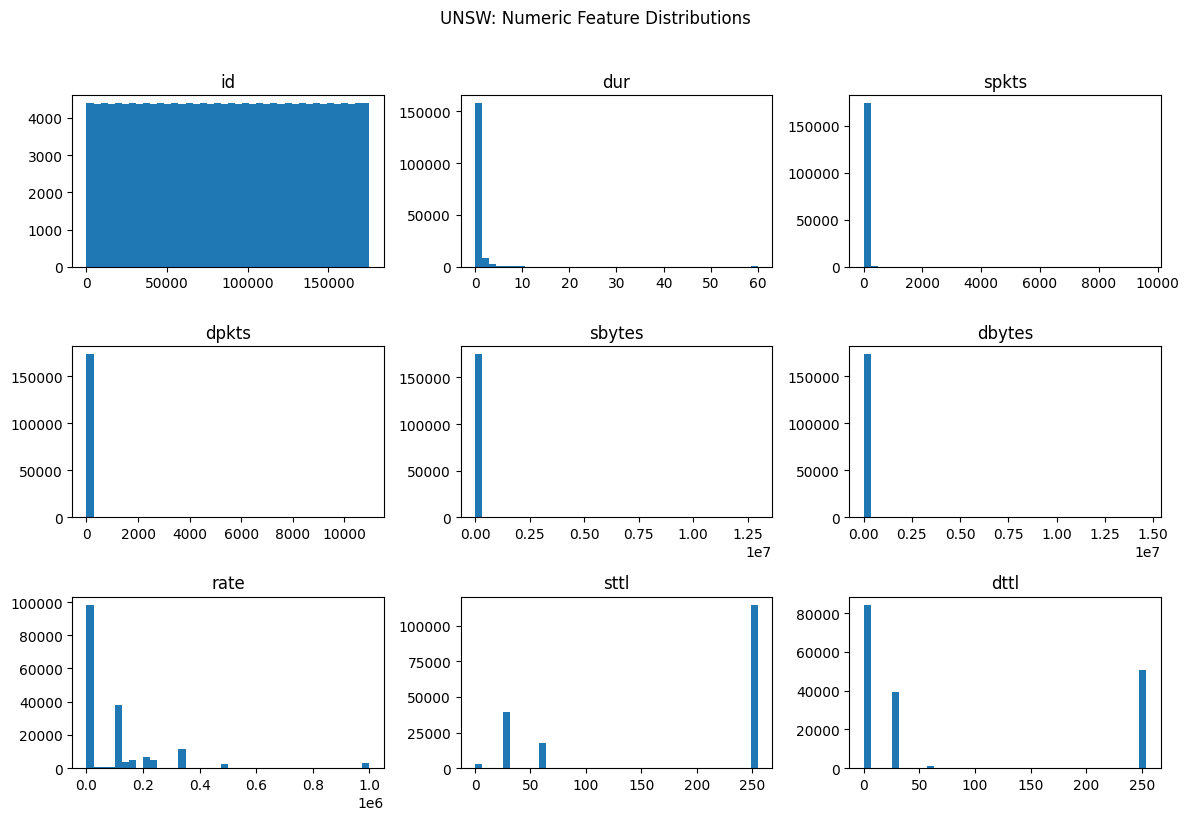

In [17]:
plot_cols = [c for c in num_cols if c != "label"][:9]

fig, axes = plt.subplots(3, 3, figsize=(12, 8))
axes = axes.flatten()

for ax, c in zip(axes, plot_cols):
    ax.hist(df[c].dropna(), bins=40)
    ax.set_title(c)

for ax in axes[len(plot_cols):]:
    ax.set_visible(False)

fig.suptitle("UNSW: Numeric Feature Distributions", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "overview_unsw_numeric_distributions.png", dpi=300, bbox_inches="tight")
plt.show()


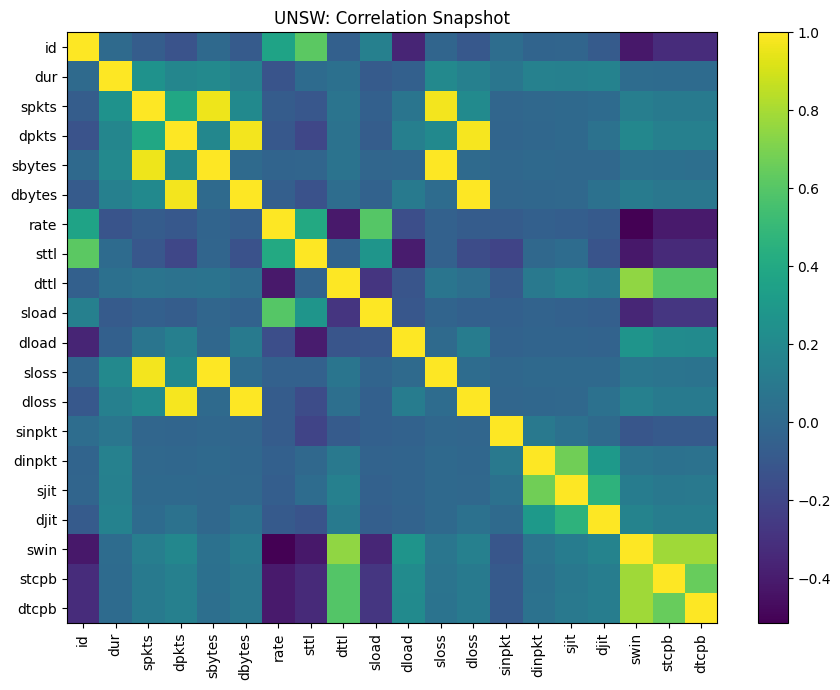

In [18]:
top_num = [c for c in num_cols if c != "label"][:20]
corr = df[top_num].corr(numeric_only=True)

plt.figure(figsize=(9, 7))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(top_num)), top_num, rotation=90)
plt.yticks(range(len(top_num)), top_num)
plt.title("UNSW: Correlation Snapshot")
plt.tight_layout()
plt.savefig(FIG_DIR / "overview_unsw_correlation_snapshot.png", dpi=300, bbox_inches="tight")
plt.show()


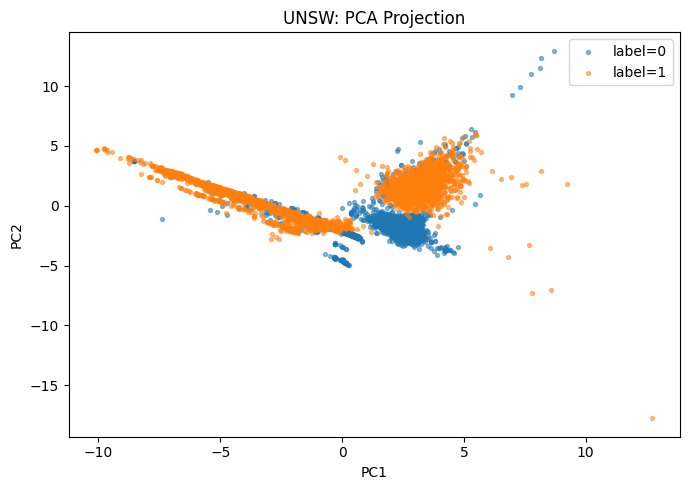

In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sample = df.sample(n=min(8000, len(df)), random_state=42)

X = sample[[c for c in num_cols if c != "label"]].dropna()
X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=2, random_state=42) if "random_state" in PCA.__init__.__code__.co_varnames else PCA(n_components=2)
Z = pca.fit_transform(X_scaled)

plot_df = sample.loc[X.index, ["label"]].copy()
plot_df["pc1"] = Z[:, 0]
plot_df["pc2"] = Z[:, 1]

plt.figure(figsize=(7, 5))
for lbl, grp in plot_df.groupby("label"):
    plt.scatter(grp["pc1"], grp["pc2"], s=8, alpha=0.5, label=f"label={lbl}")
plt.title("UNSW: PCA Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "overview_unsw_pca.png", dpi=300, bbox_inches="tight")
plt.show()


## UNSW-NB15 — Data Overview Takeaways

- The presence of a binary target (`label`) supports a supervised learning framework.
- Numeric fields show skew and overlap, so baseline linear models may be useful but unlikely to be sufficient on their own.
- Correlation and PCA views suggest that separation is not trivial, which supports using stronger nonlinear baselines and disciplined preprocessing.
- Evaluation should emphasize precision, recall, F1, and ranking-oriented metrics instead of accuracy alone.


## BETH Overview

In [20]:
df = beth_train_df.copy()

print("BETH (train) shape:", df.shape)
print("\nColumns:", df.columns.tolist())
display(df.head())


BETH (train) shape: (763144, 16)

Columns: ['timestamp', 'processId', 'threadId', 'parentProcessId', 'userId', 'mountNamespace', 'processName', 'hostName', 'eventId', 'eventName', 'stackAddresses', 'argsNum', 'returnValue', 'args', 'sus', 'evil']


,timestamp,processId,threadId,parentProcessId,userId,mountNamespace,processName,hostName,eventId,eventName,stackAddresses,argsNum,returnValue,args,sus,evil
0,1809.495787,381,7337,1,100,4026532231,close,ip-10-100-1-120,157,prctl,"[140662171848350, 11649800180280676]",5,0,"[{'name': 'option', 'type': 'int', 'value': 'P...",1,0
1,1809.495832,381,7337,1,100,4026532231,close,ip-10-100-1-120,3,close,[140662171777451],1,0,"[{'name': 'fd', 'type': 'int', 'value': 19}]",1,0
2,1809.495921,381,7337,1,100,4026532231,close,ip-10-100-1-120,1010,sched_process_exit,[],0,0,[],1,0
3,1894.139651,7347,7347,7341,0,4026531840,sh,ip-10-100-1-120,21,access,[],2,-2,"[{'name': 'pathname', 'type': 'const char*', '...",1,0
4,1894.142127,7347,7347,7341,0,4026531840,sh,ip-10-100-1-120,1005,security_file_open,"[139778263990104, 139778263906698]",4,0,"[{'name': 'pathname', 'type': 'const char*', '...",1,0


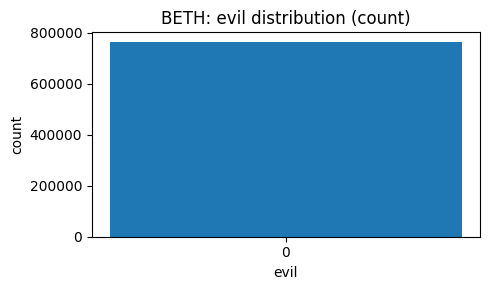

,pct
evil,
0,1.0


In [21]:
target = "evil"
vc = df[target].value_counts(dropna=False)

plt.figure(figsize=(5, 3))
plt.bar(vc.index.astype(str), vc.values)
plt.title("BETH: evil distribution (count)")
plt.xlabel("evil")
plt.ylabel("count")
plt.tight_layout()
plt.savefig(FIG_DIR / "overview_beth_evil_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

display((vc / vc.sum()).rename("pct").round(4).to_frame())


In [22]:
candidate_cols = ["processId","threadId","parentProcessId","userId","eventId","mountNamespace"]
for c in candidate_cols:
    if c in df.columns:
        print(c, "unique:", df[c].nunique(), " / rows:", len(df))


processId unique: 545  / rows: 763144
threadId unique: 588  / rows: 763144
parentProcessId unique: 205  / rows: 763144
userId unique: 7  / rows: 763144
eventId unique: 32  / rows: 763144
mountNamespace unique: 6  / rows: 763144


In [23]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

desc = df[num_cols].describe().T
desc["skew"] = df[num_cols].skew(numeric_only=True)
desc = desc.sort_values("skew", key=lambda s: s.abs(), ascending=False)

print("Top skewed numeric features:")
print(desc[["mean","std","min","50%","max","skew"]].head(15))


Top skewed numeric features:
                         mean          std           min           50%  \
userId           2.279034e+00    37.416576  0.000000e+00  0.000000e+00   
sus              1.662858e-03     0.040744  0.000000e+00  0.000000e+00   
returnValue      1.752092e+01   318.596662 -1.150000e+02  0.000000e+00   
threadId         6.820265e+03  1937.068333  1.000000e+00  7.365000e+03   
processId        6.814763e+03  1948.871187  1.000000e+00  7.365000e+03   
parentProcessId  1.882217e+03  2215.563094  0.000000e+00  1.385000e+03   
eventId          2.881590e+02   385.117778  3.000000e+00  6.200000e+01   
mountNamespace   4.026532e+09   164.902979  4.026532e+09  4.026532e+09   
argsNum          2.672082e+00     1.340906  0.000000e+00  3.000000e+00   
timestamp        1.844583e+03  1136.638249  1.325607e+02  1.829204e+03   
evil             0.000000e+00     0.000000  0.000000e+00  0.000000e+00   

                          max       skew  
userId           1.000000e+03  24.92861

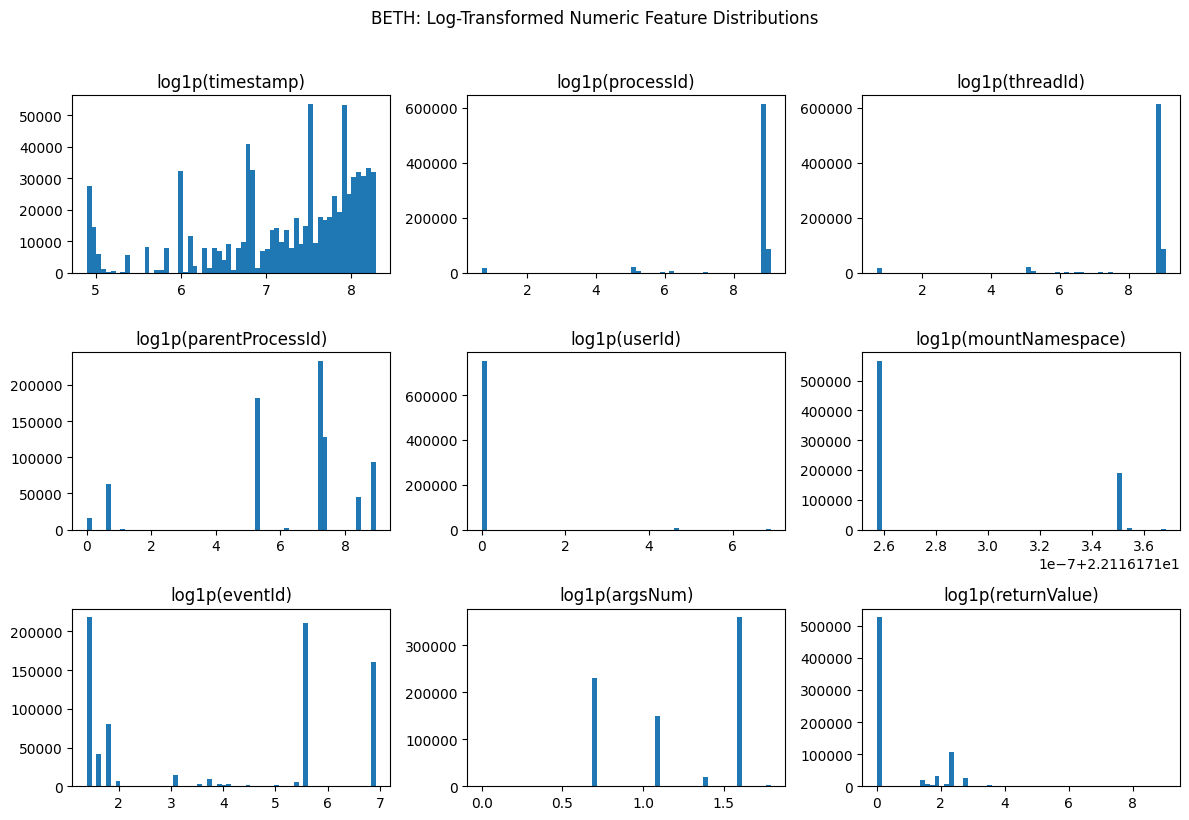

In [24]:
plot_cols = [c for c in num_cols if c != "evil"][:9]

fig, axes = plt.subplots(3, 3, figsize=(12, 8))
axes = axes.flatten()

for ax, c in zip(axes, plot_cols):
    x = df[c].dropna()
    x = x[np.isfinite(x)]
    x = x[x > -1]   # remove values that break log1p
    
    if len(x) > 0:
        ax.hist(np.log1p(x), bins=60)
        ax.set_title(f"log1p({c})")
    else:
        ax.text(0.5, 0.5, "No valid values", ha="center", va="center")
        ax.set_title(f"log1p({c})")

for ax in axes[len(plot_cols):]:
    ax.set_visible(False)

fig.suptitle("BETH: Log-Transformed Numeric Feature Distributions", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "overview_beth_log_numeric_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

In [25]:
print("BETH target distribution:")
print(beth_train_df["evil"].value_counts(dropna=False))

if beth_train_df["evil"].nunique() <= 1:
    print("\nNote:")
    print("BETH contains only benign (evil = 0) observations.")
    print("This dataset is treated as a one-class / anomaly detection problem.")


BETH target distribution:
evil
0    763144
Name: count, dtype: int64

Note:
BETH contains only benign (evil = 0) observations.
This dataset is treated as a one-class / anomaly detection problem.


In [26]:
# BETH: quantify rarity without labels
from scipy.stats import zscore

num_cols = beth_train_df.select_dtypes(include=[np.number]).columns.tolist()

zs = beth_train_df[num_cols].apply(zscore)
extreme_rate = (np.abs(zs) > 4).mean()

print("Top features by extreme-value rate:")
print(extreme_rate.sort_values(ascending=False).head(10))


Top features by extreme-value rate:
returnValue        0.002217
sus                0.001663
userId             0.001305
threadId           0.000000
processId          0.000000
timestamp          0.000000
parentProcessId    0.000000
eventId            0.000000
mountNamespace     0.000000
argsNum            0.000000
dtype: float64


In [27]:
# BETH: distribution stability check across random splits
from scipy.stats import ks_2samp

num_cols = beth_train_df.select_dtypes(include=[np.number]).columns

sample_a = beth_train_df.sample(frac=0.1, random_state=42)
sample_b = beth_train_df.sample(frac=0.1, random_state=7)

ks_results = []
for c in num_cols[:20]:
    try:
        stat, p = ks_2samp(sample_a[c].dropna(), sample_b[c].dropna())
        ks_results.append((c, stat, p))
    except Exception:
        continue

ks_df = pd.DataFrame(ks_results, columns=["feature", "ks_stat", "p_value"]).sort_values("ks_stat", ascending=False)
display(ks_df.head(10))


,feature,ks_stat,p_value
1,processId,0.002595,0.958831
2,threadId,0.002581,0.960587
0,timestamp,0.002568,0.962295
3,parentProcessId,0.002372,0.982404
8,returnValue,0.001271,1.000000
6,eventId,0.001101,1.000000
7,argsNum,0.001048,1.000000
4,userId,0.000550,1.000000
5,mountNamespace,0.000537,1.000000
9,sus,0.000157,1.000000


In [28]:
# BETH: rarity by event type
event_freq = (
    beth_train_df["eventId"]
    .value_counts(normalize=True)
    .rename("frequency")
    .reset_index()
    .rename(columns={"index": "eventId"})
)

event_freq["rarity_score"] = 1 / event_freq["frequency"]
event_freq.sort_values("rarity_score", ascending=False).head(10)


,eventId,frequency,rarity_score
31,166,0.000005,190786.000000
30,88,0.000008,127190.666667
29,292,0.000026,38157.200000
28,91,0.000086,11562.787879
26,106,0.000224,4462.830409
27,105,0.000224,4462.830409
25,43,0.000232,4311.548023
24,1006,0.000261,3834.894472
23,32,0.000464,2155.774011
22,263,0.000553,1808.398104


In [29]:
# BETH: strongest correlations only
corr = beth_train_df.select_dtypes(include=[np.number]).corr()

strong_corrs = (
    corr.abs()
        .unstack()
        .reset_index()
        .rename(columns={0: "corr"})
)

strong_corrs = strong_corrs[
    (strong_corrs["level_0"] != strong_corrs["level_1"]) &
    (strong_corrs["corr"] > 0.6)
].sort_values("corr", ascending=False)

strong_corrs.head(10)


,level_0,level_1,corr
13,processId,threadId,0.997469
23,threadId,processId,0.997469
53,userId,sus,0.856705
103,sus,userId,0.856705
73,eventId,argsNum,0.631485
83,argsNum,eventId,0.631485


In [30]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X_beth = beth_train_df.select_dtypes(include=[np.number]).dropna()

X_scaled = StandardScaler().fit_transform(X_beth)

pca = PCA().fit(X_scaled)

explained = pd.DataFrame({
    "component": range(1, len(pca.explained_variance_ratio_) + 1),
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative_explained_variance": np.cumsum(pca.explained_variance_ratio_)
})

display(explained.head(10))


,component,explained_variance_ratio,cumulative_explained_variance
0,1,0.234202,0.234202
1,2,0.186850,0.421052
2,3,0.168590,0.589642
3,4,0.139862,0.729504
4,5,0.099288,0.828792
5,6,0.074884,0.903676
6,7,0.047269,0.950945
7,8,0.034900,0.985845
8,9,0.013906,0.999751
9,10,0.000249,1.000000


In [31]:
# BETH: distance to centroid (simple anomaly intuition)
centroid = X_scaled.mean(axis=0)
distances = np.linalg.norm(X_scaled - centroid, axis=1)

beth_train_df["distance_from_centroid"] = distances

beth_train_df["distance_from_centroid"].describe(percentiles=[0.9, 0.95, 0.99])


count    763144.000000
mean          2.554517
std           1.863986
min           0.786672
50%           2.298956
90%           3.373583
95%           5.261380
99%           5.841860
max          36.624195
Name: distance_from_centroid, dtype: float64

### Modeling Decisions Explicitly Avoided (BETH)

To preserve methodological correctness, the following are intentionally excluded at this stage:

- supervised classification when no positive class is meaningfully available
- accuracy-based evaluation as a primary success metric
- synthetic labeling or oversampling to invent positives
- treating the dataset as a standard binary classification problem without validating label support


## Cyber Attacks Overview

In [32]:
print("Shape:", cyber_df.shape)
print("\nColumns:\n", cyber_df.columns.tolist())
display(cyber_df.head())


Shape: (40000, 25)

Columns:
 ['Timestamp', 'Source IP Address', 'Destination IP Address', 'Source Port', 'Destination Port', 'Protocol', 'Packet Length', 'Packet Type', 'Traffic Type', 'Payload Data', 'Malware Indicators', 'Anomaly Scores', 'Alerts/Warnings', 'Attack Type', 'Attack Signature', 'Action Taken', 'Severity Level', 'User Information', 'Device Information', 'Network Segment', 'Geo-location Data', 'Proxy Information', 'Firewall Logs', 'IDS/IPS Alerts', 'Log Source']


,Timestamp,Source IP Address,Destination IP Address,Source Port,Destination Port,Protocol,Packet Length,Packet Type,Traffic Type,Payload Data,...,Action Taken,Severity Level,User Information,Device Information,Network Segment,Geo-location Data,Proxy Information,Firewall Logs,IDS/IPS Alerts,Log Source
0,2023-05-30 06:33:58,103.216.15.12,84.9.164.252,31225,17616,ICMP,503,Data,HTTP,Qui natus odio asperiores nam. Optio nobis ius...,...,Logged,Low,Reyansh Dugal,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment A,"Jamshedpur, Sikkim",150.9.97.135,Log Data,NaN,Server
1,2020-08-26 07:08:30,78.199.217.198,66.191.137.154,17245,48166,ICMP,1174,Data,HTTP,Aperiam quos modi officiis veritatis rem. Omni...,...,Blocked,Low,Sumer Rana,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment B,"Bilaspur, Nagaland",NaN,Log Data,NaN,Firewall
2,2022-11-13 08:23:25,63.79.210.48,198.219.82.17,16811,53600,UDP,306,Control,HTTP,Perferendis sapiente vitae soluta. Hic delectu...,...,Ignored,Low,Himmat Karpe,Mozilla/5.0 (compatible; MSIE 9.0; Windows NT ...,Segment C,"Bokaro, Rajasthan",114.133.48.179,Log Data,Alert Data,Firewall
3,2023-07-02 10:38:46,163.42.196.10,101.228.192.255,20018,32534,UDP,385,Data,HTTP,Totam maxime beatae expedita explicabo porro l...,...,Blocked,Medium,Fateh Kibe,Mozilla/5.0 (Macintosh; PPC Mac OS X 10_11_5; ...,Segment B,"Jaunpur, Rajasthan",NaN,NaN,Alert Data,Firewall
4,2023-07-16 13:11:07,71.166.185.76,189.243.174.238,6131,26646,TCP,1462,Data,DNS,Odit nesciunt dolorem nisi iste iusto. Animi v...,...,Blocked,Low,Dhanush Chad,Mozilla/5.0 (compatible; MSIE 5.0; Windows NT ...,Segment C,"Anantapur, Tripura",149.6.110.119,NaN,Alert Data,Firewall


In [33]:
dtypes = cyber_df.dtypes.value_counts()
print("Dtype counts:")
print(dtypes)

num_cols = cyber_df.select_dtypes(include=[np.number]).columns.tolist()
obj_cols = cyber_df.select_dtypes(include=["object"]).columns.tolist()

print("\nNumeric columns:", len(num_cols))
print("Object columns:", len(obj_cols))

# High-cardinality check for object columns
cardinality = pd.Series({c: cyber_df[c].nunique(dropna=False) for c in obj_cols}).sort_values(ascending=False)
display(cardinality.head(15))


Dtype counts:
object     21
int64       3
float64     1
Name: count, dtype: int64

Numeric columns: 4
Object columns: 21


Source IP Address         40000
Destination IP Address    40000
Payload Data              40000
Timestamp                 39997
User Information          32389
Device Information        32104
Proxy Information         20149
Geo-location Data          8723
Protocol                      3
Network Segment               3
Traffic Type                  3
Action Taken                  3
Attack Type                   3
Severity Level                3
Packet Type                   2
dtype: int64

In [34]:
# Attack Type distribution
if "Attack Type" in cyber_df.columns:
    attack_counts = cyber_df["Attack Type"].value_counts(dropna=False)
    display(attack_counts)
    print("\nAttack Type %:")
    display((attack_counts / len(cyber_df) * 100).round(2))

# Severity Level distribution
if "Severity Level" in cyber_df.columns:
    sev_counts = cyber_df["Severity Level"].value_counts(dropna=False)
    display(sev_counts)


Attack Type
DDoS         13428
Malware      13307
Intrusion    13265
Name: count, dtype: int64


Attack Type %:


Attack Type
DDoS         33.57
Malware      33.27
Intrusion    33.16
Name: count, dtype: float64

Severity Level
Medium    13435
High      13382
Low       13183
Name: count, dtype: int64

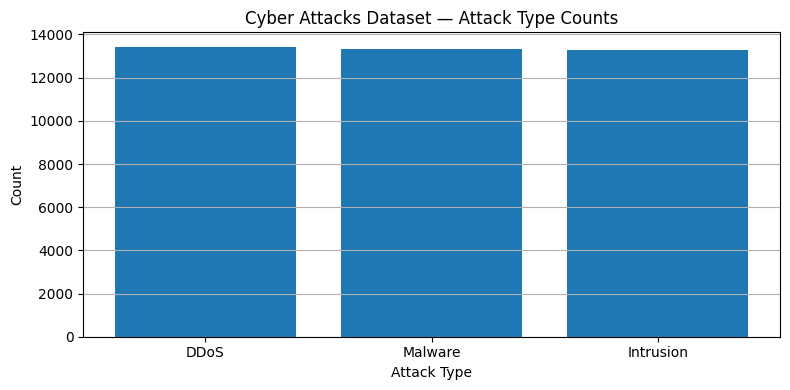

In [35]:

attack_counts = cyber_df["Attack Type"].value_counts()

plt.figure(figsize=(8,4))
plt.bar(attack_counts.index.astype(str), attack_counts.values)
plt.title("Cyber Attacks Dataset — Attack Type Counts")
plt.xlabel("Attack Type")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.grid(True, axis="y")
plt.tight_layout()
plt.savefig(FIG_DIR / "overview_cyber_attack_type_counts.png", dpi=300, bbox_inches="tight")
plt.show()


In [36]:
# Core numeric columns you usually care about in this dataset
focus = [c for c in ["Packet Length", "Anomaly Scores", "Source Port", "Destination Port"] if c in cyber_df.columns]

summary = cyber_df[focus].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).T
display(summary)

# Outlier share at 99th percentile (simple, interpretable)
outlier_share = {}
for c in focus:
    q99 = cyber_df[c].quantile(0.99)
    outlier_share[c] = float((cyber_df[c] > q99).mean())
pd.DataFrame({"feature": outlier_share.keys(), "pct_above_99th": np.round(np.array(list(outlier_share.values()))*100, 2)})


,count,mean,std,min,50%,90%,95%,99%,max
Packet Length,40000.0,781.452725,416.044192,64.0,782.000,1356.0,1427.00,1486.0000,1500.0
Anomaly Scores,40000.0,50.113473,28.853598,0.0,50.345,90.0,94.87,99.0001,100.0
Source Port,40000.0,32970.356450,18560.425604,1027.0,32856.000,58833.1,62203.15,64889.0200,65530.0
Destination Port,40000.0,33150.868650,18574.668842,1024.0,33004.500,58883.2,62161.20,64853.0000,65535.0


,feature,pct_above_99th
0,Packet Length,0.97
1,Anomaly Scores,1.00
2,Source Port,1.00
3,Destination Port,1.00


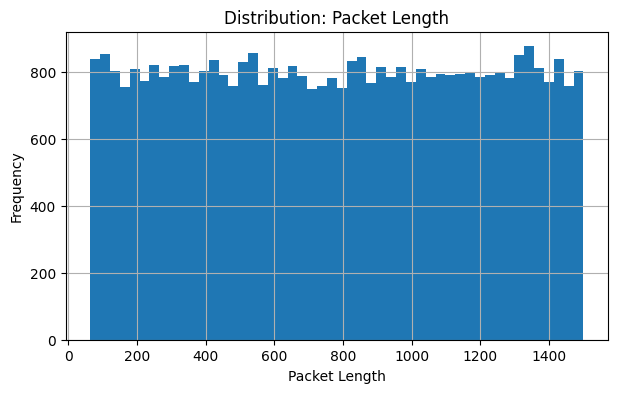

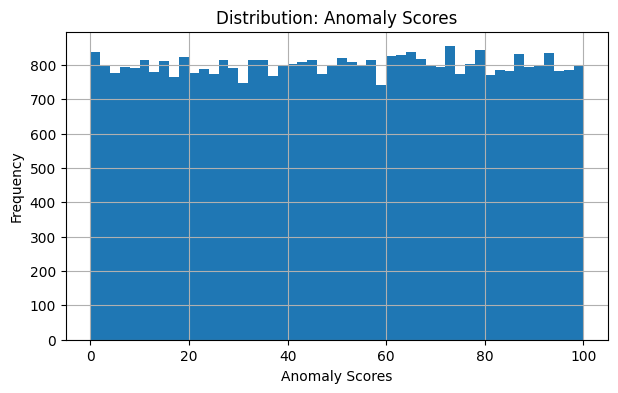

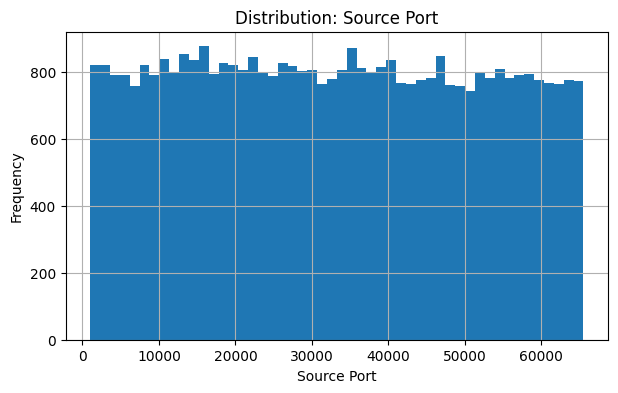

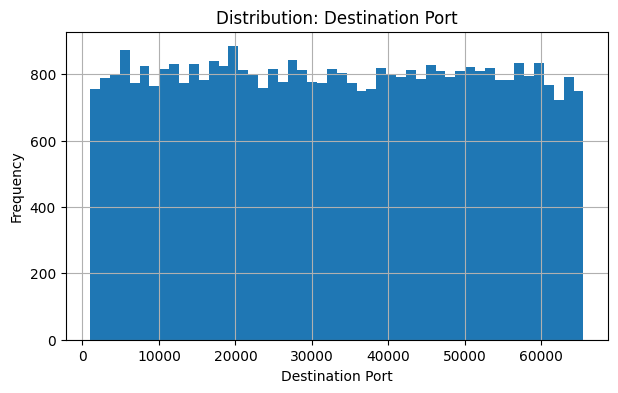

In [37]:

focus = [c for c in ["Packet Length", "Anomaly Scores", "Source Port", "Destination Port"] if c in cyber_df.columns]

for c in focus:
    plt.figure(figsize=(7,4))
    x = cyber_df[c].dropna()
    plt.hist(x, bins=50)
    plt.title(f"Distribution: {c}")
    plt.xlabel(c)
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()

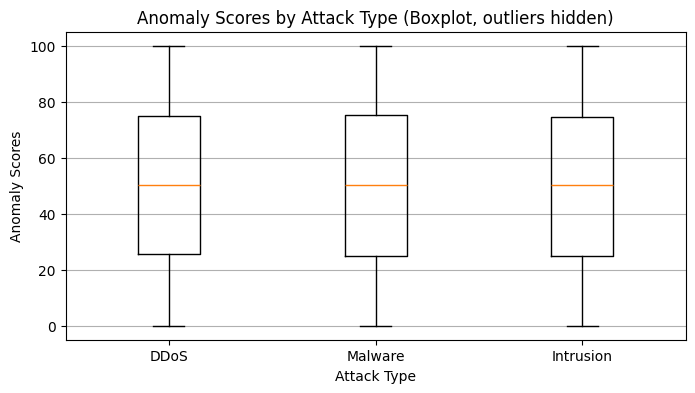

In [38]:

if "Attack Type" in cyber_df.columns and "Anomaly Scores" in cyber_df.columns:
    groups = cyber_df[["Attack Type", "Anomaly Scores"]].dropna()
    
    # Use a consistent class order
    order = groups["Attack Type"].value_counts().index.tolist()
    
    plt.figure(figsize=(8,4))
    data = [groups.loc[groups["Attack Type"] == t, "Anomaly Scores"].values for t in order]
    plt.boxplot(data, labels=[str(t) for t in order], showfliers=False)
    plt.title("Anomaly Scores by Attack Type (Boxplot, outliers hidden)")
    plt.xlabel("Attack Type")
    plt.ylabel("Anomaly Scores")
    plt.grid(True, axis="y")
    plt.show()

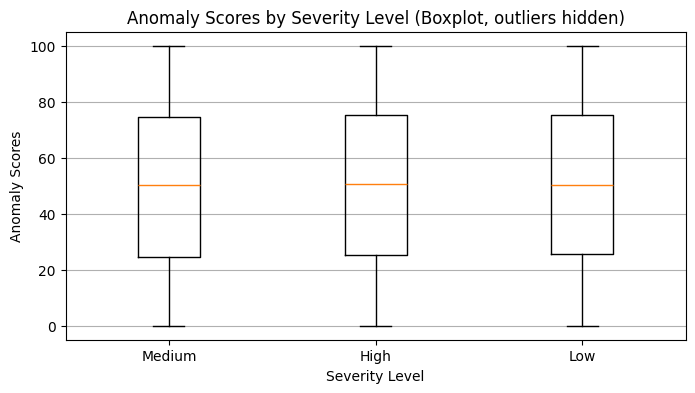

In [39]:

if "Severity Level" in cyber_df.columns and "Anomaly Scores" in cyber_df.columns:
    tmp = cyber_df[["Severity Level", "Anomaly Scores"]].dropna()
    order = tmp["Severity Level"].value_counts().index.tolist()
    
    plt.figure(figsize=(8,4))
    data = [tmp.loc[tmp["Severity Level"] == s, "Anomaly Scores"].values for s in order]
    plt.boxplot(data, labels=[str(s) for s in order], showfliers=False)
    plt.title("Anomaly Scores by Severity Level (Boxplot, outliers hidden)")
    plt.xlabel("Severity Level")
    plt.ylabel("Anomaly Scores")
    plt.grid(True, axis="y")
    plt.show()

In [40]:
# Choose a small set of categorical fields that might matter
cat_cols = [c for c in ["Protocol", "Traffic Type", "Packet Type", "Action Taken", "Network Segment"] if c in cyber_df.columns]

for c in cat_cols:
    if "Attack Type" in cyber_df.columns:
        cross = pd.crosstab(cyber_df[c], cyber_df["Attack Type"], normalize="columns") * 100
        display(cross.round(2).head(15))


Attack Type,DDoS,Intrusion,Malware
Protocol,,,
ICMP,33.57,33.62,33.52
TCP,33.05,33.15,33.34
UDP,33.38,33.23,33.13


Attack Type,DDoS,Intrusion,Malware
Traffic Type,,,
DNS,33.72,33.37,33.23
FTP,32.69,33.57,33.23
HTTP,33.59,33.06,33.54


Attack Type,DDoS,Intrusion,Malware
Packet Type,,,
Control,49.74,50.92,51.12
Data,50.26,49.08,48.88


Attack Type,DDoS,Intrusion,Malware
Action Taken,,,
Blocked,33.76,34.32,33.39
Ignored,33.21,33.18,33.19
Logged,33.04,32.50,33.43


Attack Type,DDoS,Intrusion,Malware
Network Segment,,,
Segment A,33.10,32.79,33.66
Segment B,33.26,33.90,32.73
Segment C,33.64,33.31,33.61


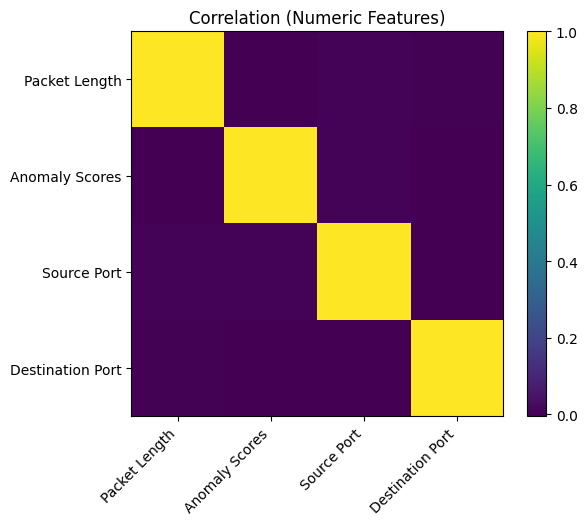

In [41]:

# Only keep numeric columns with enough variance
num_df = cyber_df.select_dtypes(include=[np.number]).copy()

# Drop constant columns
nunique = num_df.nunique()
num_df = num_df.loc[:, nunique > 1]

# If too many numeric columns, focus on top few you care about
candidate = [c for c in ["Packet Length", "Anomaly Scores", "Source Port", "Destination Port"] if c in num_df.columns]
if len(candidate) >= 2:
    corr = num_df[candidate].corr()
else:
    corr = num_df.corr()

plt.figure(figsize=(6,5))
plt.imshow(corr, aspect="auto")
plt.title("Correlation (Numeric Features)")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
plt.colorbar()
plt.grid(False)
plt.show()

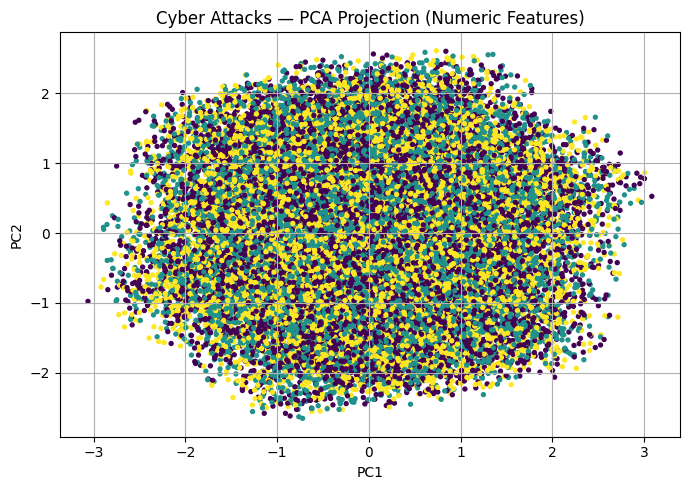

Explained variance ratio: [0.252 0.251]


In [42]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Build numeric-only matrix for projection
use_cols = [c for c in ["Packet Length", "Anomaly Scores", "Source Port", "Destination Port"] if c in cyber_df.columns]
X = cyber_df[use_cols].dropna()

# Align y to X index (only if Attack Type exists)
y = None
if "Attack Type" in cyber_df.columns:
    y = cyber_df.loc[X.index, "Attack Type"].astype(str)

X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=2, random_state=42)
X_p = pca.fit_transform(X_scaled)

plt.figure(figsize=(7,5))
if y is None:
    plt.scatter(X_p[:,0], X_p[:,1], s=8)
else:
    # Simple color by class using category codes
    codes = pd.Categorical(y).codes
    plt.scatter(X_p[:,0], X_p[:,1], c=codes, s=8)
plt.title("Cyber Attacks — PCA Projection (Numeric Features)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.tight_layout()
plt.savefig(FIG_DIR / "overview_cyber_pca.png", dpi=300, bbox_inches="tight")
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_.round(3))

In [43]:
implications = []

# overlap check
if "Attack Type" in cyber_df.columns and "Anomaly Scores" in cyber_df.columns:
    by_class = cyber_df.groupby("Attack Type")["Anomaly Scores"].agg(["mean", "std", "min", "max"])
    implications.append(("Anomaly Scores", "By-class summary suggests whether the 'score' separates attack types."))

# missingness
missing_cells_pct = float(cyber_df.isna().mean().mean() * 100)
implications.append(("Missingness", f"Overall missing-cell rate ~ {missing_cells_pct:.2f}% — informs cleaning strategy."))

# high-cardinality note
obj_cols = cyber_df.select_dtypes(include=["object"]).columns.tolist()
high_card = [c for c in obj_cols if cyber_df[c].nunique() > 50]
implications.append(("High-cardinality fields", f"{len(high_card)} object columns have high cardinality; drop or encode carefully (risk of leakage/overfit)."))

pd.DataFrame(implications, columns=["EDA Finding", "Modeling implication"])


if implications:
    display(pd.DataFrame(implications, columns=["area", "implication"]))


,area,implication
0,Anomaly Scores,By-class summary suggests whether the 'score' ...
1,Missingness,Overall missing-cell rate ~ 9.99% — informs cl...
2,High-cardinality fields,8 object columns have high cardinality; drop o...


## 6) Modeling Implications

This notebook establishes the constraints that should carry forward into the downstream modeling work.

- **UNSW-NB15**: supervised classification is appropriate. Expect skew, overlap, and the need for metrics beyond accuracy.
- **BETH**: anomaly detection remains the more defensible framing unless positive labels are shown to be stable and sufficiently represented.
- **Cybersecurity Attacks**: multiclass modeling is viable, but preprocessing, overlap, and class imbalance should be monitored closely.
- **Operational extension**: the path/config pattern in this notebook is intentionally simple today, but it can later be extended to Azure-backed storage, environment-based configuration, and scheduled validation workflows without changing the analytical logic.

Next step: move into the dataset-specific modeling notebooks using the constraints documented here.
